# Setup & Imports

In [75]:
import pandas as pd

import matplotlib.pyplot as plt

import json

from pathlib import Path
pd.reset_option('display.max_rows')

# Load Data

In [76]:
BASE_DIR = Path("S:/Zulassungskarten_Data")

metadata = []

for json_path in BASE_DIR.rglob("*.json"):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

            data["_source_folder"] = json_path.parent.name
            data["_file_name"] = json_path.name

            metadata.append(data)

    except (json.JSONDecodeError, IOError) as e:
        print(f"Fehler beim Lesen von {json_path}: {e}")

df = pd.DataFrame(metadata)
df

,Titel_und_Signatur,Bemerkung,Prüfnummer,Prüfdatum,Antragsteller,Produktion,Land,Filmart,Stumm-/Tonfilm,Länge (in Meter),...,129,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,33564,31.3.1933,"Comedia Tonfilm GmbH, Berlin",Kulturfilm,374,Jugendfrei
0,R 9346-I/1\nDie Wölfin.\n1920 - 1945,nach Kürzung 1480 m,2,24.6.1920,"Solar-Film-Ges., Berlin","Solar-Film-Ges., Berlin",Deutschland,Puppenfilm,Stummfilm,1485,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,R 9346-I/10\nDie tote Stunde\n1920 - 1945,NaN,52,5.7.1920,"Ungo-Film-Ges. Unger u. Gottschalk, Berlin","Ungo-Film-Ges. Unger u. Gottschalk, Berlin",Deutschland,Spielfilm,Stummfilm,1715,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,R 9346-I/100\nNur ein Flimmerstern\n1920,NaN,527,2.10.1920,"Ebert-Film GmbH, Berlin","Ebert-Film GmbH, Berlin",Deutschland,Spielfilm,Stummfilm,1135,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,R 9346-I/1000\nSein Pelzmäuschen.\n1920 - 1945,"nach Kürzung 695,30 m",2320,20.5.1921,"Liddy Hegewalds-Film-Verleih, Leipzig","Rirefilm, Berlin",Deutschland,Spielfilm,Stummfilm,699,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,R 9346-I/9899\nDas Flugzeug im deutschen Wirts...,NaN,14750,15.1.1927,"Otto Witte, Berlin","Otto Witte, Berlin",Deutschland,Kulturfilm,Stummfilm,564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35652,"R 9346-I/5301\nDeulig-Woche Nr. 20/21, 1924.\n...",NaN,8514,21.5.1924,Deulig-Film,Deulig-Film,Deutschland,Kulturfilm,Stummfilm,146,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35653,"R 9346-I/5473\n""Er"" sprengt die Bank.\n1920 - ...",NaN,8747,25.7.1924,"Margulies-Film GmbH, Berlin","Pathé Exchange, New York",USA,Spielfilm,Stummfilm,540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35654,"R 9346-I/6196\nKurt kam, sah und siegte\n1920 ...",NaN,9701,22.1.1925,"Trianon-Film AG, Berlin","Trianon-Film AG, Berlin",Deutschland,Spielfilm,Stummfilm,740,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35655,"R 9346-I/7938\nliebe gute Weihnachtsmann, Der\...",NaN,12016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Cleaning

In [77]:
# convert string to datetime
df['Prüfdatum'] = pd.to_datetime(df['Prüfdatum'], errors='coerce')

# extract year from Datetime and save in extra column
df['Jahr'] = df['Prüfdatum'].dt.year.astype('Int64')


# convert Prüfnummer to number
df['Prüfnummer'] = pd.to_numeric(df['Prüfnummer'], errors='coerce')

# sort by Prüfnummer
df = df.sort_values(by='Prüfnummer')

df

C:\Users\maris\AppData\Local\Temp\ipykernel_14232\2689736599.py:2: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Prüfdatum'] = pd.to_datetime(df['Prüfdatum'], errors='coerce')


,Titel_und_Signatur,Bemerkung,Prüfnummer,Prüfdatum,Antragsteller,Produktion,Land,Filmart,Stumm-/Tonfilm,Länge (in Meter),...,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,33564,31.3.1933,"Comedia Tonfilm GmbH, Berlin",Kulturfilm,374,Jugendfrei,Jahr
0,R 9346-I/1\nDie Wölfin.\n1920 - 1945,nach Kürzung 1480 m,2.0,1920-06-24,"Solar-Film-Ges., Berlin","Solar-Film-Ges., Berlin",Deutschland,Puppenfilm,Stummfilm,1485,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1920
10688,R 9346-I/2\nDie Spieler\n1920 - 1945,NaN,7.0,1920-06-25,"Asslan-Film Continental, Berlin","Asslan-Film Continental, Berlin",Deutschland,Spielfilm,Stummfilm,2379,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1920
21694,R 9346-I/3\nSowas kommt von Sowas\n1920 - 1945,NaN,9.0,1920-06-24,"Karfiol-Film, Berlin","Karfiol-Film, Berlin",Deutschland,Spielfilm,Stummfilm,505,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1920
28971,R 9346-I/4\nDer Gefangene. (Sklaven des XX. Ja...,LF260322: Durch Blut und Eisen,11.0,1920-07-09,"Kowo Gesellschaft, Berlin","Kowo Gesellschaft, Berlin",Deutschland,Spielfilm,Stummfilm,1833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1920
30075,R 9346-I/5\nDie entfesselte Menschheit\n1920 -...,NaN,20.0,1920-06-29,"Nivo-Film-Comp. GmbH, Berlin","Nivo-Film-Comp. GmbH, Berlin",Deutschland,Spielfilm,Stummfilm,2453,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28226,R 9346-I/36249\nEs lebe die Liebe.\n1920 - 1945,NaN,NaN,1944-05-17,"Bavaria-Filmkunst GmbH, München-Geiselgasteig","Bavaria-Filmkunst GmbH, München-Geiselgasteig",Deutschland,Spielfilm,Tonfilm,2428,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1944
28500,R 9346-I/36536\nDrei ehrliche Banditen.,Originalquelle Zulassungskarte unvollständig O...,NaN,NaT,Deutsche Vereinsfilm AG,Fox-Film Corporation,USA,Spielfilm,Stummfilm,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
28503,R 9346-I/36539\nDie Macht der Versuchung.\n192...,Originalquelle Zulassungskarte unvollständig (...,NaN,NaT,Projektions-AG Union (PAGU),Projektions-AG Union (PAGU),Deutschland,Spielfilm,Stummfilm,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
28584,R 9346-I/36611\nAlgol (Der Tragödie der Macht....,"nur 1 Blatt, ohne Prüfnummer",NaN,NaT,Universum-Film Aktiengesellschaft,Universum-Film Aktiengesellschaft,Deutschland,Spielfilm,Stummfilm,2144,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>


## Analyze some weird findings

In [78]:
#gefilterter_df = df[df['Vorführungsbeschränkung'].notna()]

#gefilterter_df


gefiltertes_df = df[
    df['Vorführungsbeschränkung'].notna() 
    & (df['Vorführungsbeschränkung'] != "Für Jugendveranstaltungen der Filmtheaterbesitzer nicht geeignet") 
    & (df['Vorführungsbeschränkung'] != "Für Jugendveranstaltungen der Filmtheaterbesitzer nicht geeignet.")
    & (df['Vorführungsbeschränkung'] != "Für Jugendveranstaltungen der Filmtheaterbesitzer geeignet.")
    & (df['Vorführungsbeschränkung'] != "Für Jugendveranstaltungen der Filmtheaterbesitzer geeignet")
    & (df['Vorführungsbeschränkung'] != "Für Jugendveranstaltungen der Filmtheaterbesitzer nicht geeignet. <")
    & (df['Vorführungsbeschränkung'] != "Der Film ist zur Vorführung am Karfreitag, am Bußtag und am Heldengedenktag geeignet.")
    & (df['Vorführungsbeschränkung'] != "Nur in Veranstaltungen der Deutschen Reichsbahn und im Rahmen der Wehrmachtsbetreuung")
    & (df['Vorführungsbeschränkung'] != "Teilverbote")
    & (df['Vorführungsbeschränkung'] != "Nur mit Vortrag von approb. Arzt. Jugendliche nur nach Geschlechtern getrennt in Sondervorstellungen im Interesse der Jugendpflege")
    & (df['Vorführungsbeschränkung'] != "keine")
    & (df['Vorführungsbeschränkung'] != "nicht vor Jugendlichen")
    ]

gefiltertes_df

,Titel_und_Signatur,Bemerkung,Prüfnummer,Prüfdatum,Antragsteller,Produktion,Land,Filmart,Stumm-/Tonfilm,Länge (in Meter),...,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,33564,31.3.1933,"Comedia Tonfilm GmbH, Berlin",Kulturfilm,374,Jugendfrei,Jahr
28589,R 9346-I/36624\nSorgenkinder\n1920 - 1945,"nach Kürzung 308 m ""folgender Teil ist verbote...",1696.0,1921-03-29,NaN,Piccolo Grotesk Film-Ges.,Deutschland,Spielfilm,Stummfilm,312,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1921
28903,"R 9346-I/3938\nBethel, der Werdegang eines Naz...",NaN,6630.0,1922-10-13,Deulig-Film,Deulig-Film,Deutschland,Kulturfilm,Stummfilm,424,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1922
29238,R 9346-I/4240\nTragödie der Liebe. 1. u. 2. Te...,NaN,7048.0,1923-03-06,"May-Film GmbH, Berlin","May-Film GmbH, Berlin",Deutschland,Spielfilm,Stummfilm,3729,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1923
29841,R 9346-I/4788\nVölkermai.\n1920 - 1945,"nach Kürzung 1651,97 m",7785.0,1923-10-17,Film-Industrie u. Handels-AG,Filmindustrie u. Handels-AG,Deutschland,Kulturfilm,Stummfilm,1716,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1923
29842,R 9346-I/4789\nDes Gesandten Worowsky letzte F...,"nach Kürzung 657,91 m",7786.0,1923-10-17,Film-Industrie u. Handels-AG,Filmindustrie u. Handels-AG,Deutschland,Kulturfilm,Stummfilm,670,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27992,R 9346-I/35857\nFritze Bollmann wollte angeln\...,NaN,59076.0,1943-06-15,"Tobis Filmkunst GmbH, Berlin","Tobis Filmkunst GmbH, Berlin",Deutschland,Kulturfilm,Tonfilm,2327,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943
28045,R 9346-I/35904\nSchwarz auf Weiss\n1920 - 1945,NaN,59349.0,1943-09-15,"Wien-Film GmbH, Wien","Wien-Film GmbH, Wien",Deutschland,Spielfilm,Tonfilm,2373,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943
28059,R 9346-I/35917\nPetterson u. Bendel (2. Fassun...,NaN,59373.0,1943-09-18,"Konrad Urban, Film-Vertrieb und Verleih, Berlin","A/B Wive-Film, Stockholm",Schweden,Spielfilm,Tonfilm,2277,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943
28298,R 9346-I/36313\nDer Wille zum Leben\n1920 - 1945,NaN,60439.0,1944-07-25,"Wien-Film GmbH, Wien","Wien-Film GmbH, Wien",Deutschland,Kulturfilm,Tonfilm,1245,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1944


In [79]:
ausprägungen_count = df['Vorführungsbeschränkung'].value_counts()

#pd.set_option("display.max_rows", None)
print(ausprägungen_count)

Vorführungsbeschränkung
Der Film ist zur Vorführung am Karfreitag, am Bußtag und am Heldengedenktag geeignet.                                                   81
Nach Änderungen an Zwischentiteln zugelassen                                                                                            20
Nach Entfernung von Zwischentitel zugelassen                                                                                            12
Nach Entfernung von Zwischentitel(n)                                                                                                    12
Für Jugendveranstaltungen der Filmtheaterbesitzer nicht geeignet.                                                                        9
                                                                                                                                        ..
Der Film wird zur öffentlichen Vorführung im Deutschen Reiche, auch vor Jugendlichen vom vollendeten 14. Lebensjahre ab, zugelassen.     1
Nur

In [80]:
#gefiltertes_df = df[df['Vorführungsbeschränkung'] == "Nur von Ärzten und Medizinstudierenden"]
#pd.set_option("display.max_rows")

gefiltertes_df = df[df['Vorführungsbeschränkung'] == "Nur in Veranstaltungen der Wehrmacht"]

gefiltertes_df

,Titel_und_Signatur,Bemerkung,Prüfnummer,Prüfdatum,Antragsteller,Produktion,Land,Filmart,Stumm-/Tonfilm,Länge (in Meter),...,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,33564,31.3.1933,"Comedia Tonfilm GmbH, Berlin",Kulturfilm,374,Jugendfrei,Jahr
27001,R 9346-I/34872\nHilfskreuzer auf allen Meeren\...,NaN,57207.0,1942-05-16,"Marine-Hauptfilm- u. Bildstelle, Berlin","Marine-Hauptfilm- u. Bildstelle, Berlin",Deutschland,Kulturfilm,Tonfilm,581,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1942
27825,R 9346-I/35705\nSeegefecht bei Jan Mayen\n1920...,NaN,58745.0,1943-03-17,"Oberkommando der Kriegsmarine (AMA,M Wehr III ...","Oberkommando der Kriegsmarine (AMA,M Wehr III ...",Deutschland,Kulturfilm,Tonfilm,187,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943
27953,R 9346-I/35821\nHilfskreuzer-Atlantis\n1920 - ...,NaN,58973.0,1943-05-11,"Oberkommando der Kriegsmarine (AMA,M Wehr III ...","Oberkommando der Kriegsmarine (AMA,M Wehr III ...",Deutschland,Kulturfilm,Stummfilm,646,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943


# Statistical Analysis

## Descriptive 

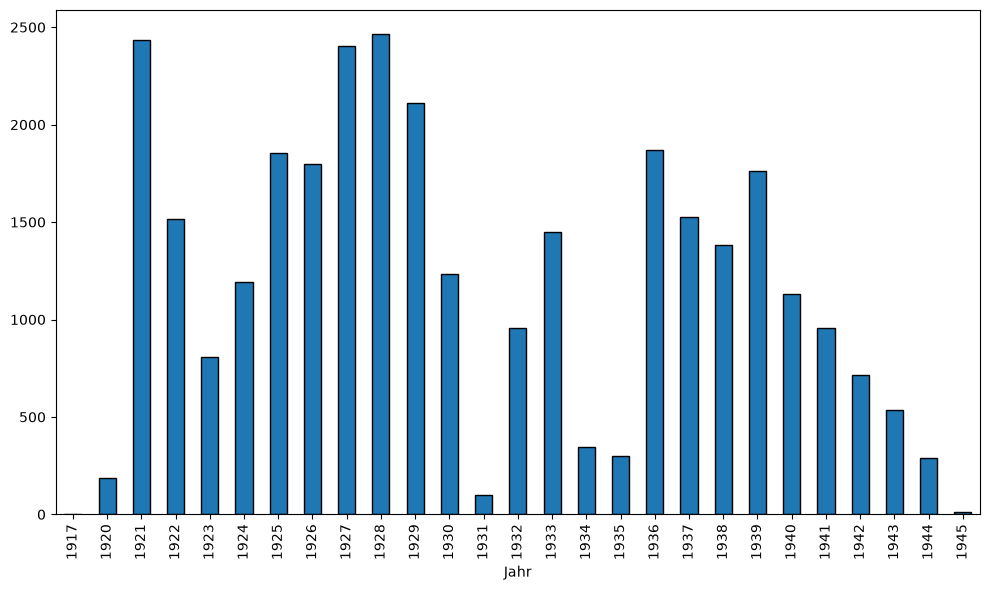

In [ ]:
counts_per_year = df['Jahr'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
counts_per_year.plot(kind='bar', color='#1f77b4', edgecolor='black')

plt.tight_layout()
plt.show()

## Reconstruction lost Documents

In [82]:
summary = df.groupby('Jahr').agg(
    Eintraege_im_DF=('Prüfnummer', 'count'),
    Anfangs_Prüfnummer=('Prüfnummer', 'min'),
    End_Prüfnummer=('Prüfnummer', 'max')
).reset_index()

summary['Theoretische_Dokumente'] = summary['End_Prüfnummer'] - summary['Anfangs_Prüfnummer'] + 1
summary['Differenz_Fehlend'] = summary['Theoretische_Dokumente'] - summary['Eintraege_im_DF']

summary = summary[['Jahr', 'Anfangs_Prüfnummer', 'End_Prüfnummer', 'Theoretische_Dokumente', 'Eintraege_im_DF', 'Differenz_Fehlend']]

print(summary.to_string(index=False))

 Jahr  Anfangs_Prüfnummer  End_Prüfnummer  Theoretische_Dokumente  Eintraege_im_DF  Differenz_Fehlend
 1917             44503.0         44615.0                   113.0                3              110.0
 1920                 2.0          2731.0                  2730.0              186             2544.0
 1921                22.0         23557.0                 23536.0             2433            21103.0
 1922              2491.0          6882.0                  4392.0             1514             2878.0
 1923              2887.0          7986.0                  5100.0              807             4293.0
 1924              6912.0          9600.0                  2689.0             1195             1494.0
 1925              9601.0         12101.0                  2501.0             1855              646.0
 1926             11934.0         14622.0                  2689.0             1797              892.0
 1927             14536.0         18894.0                  4359.0             2402

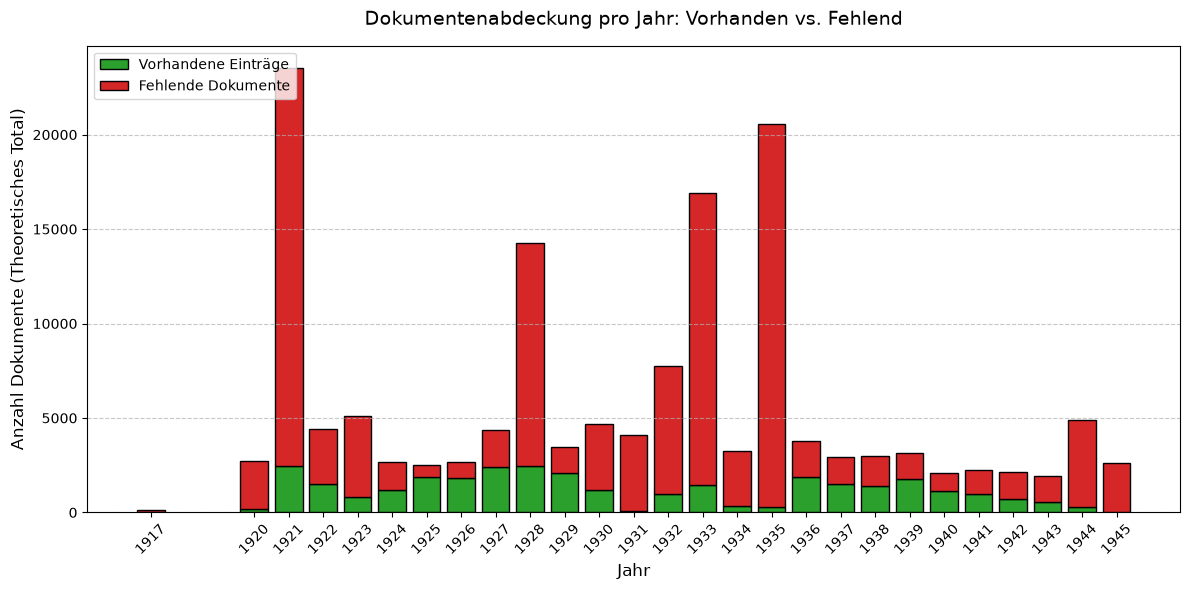

In [83]:


# drop na
plot_df = summary.dropna(subset=['Jahr']).copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    plot_df['Jahr'], 
    plot_df['Eintraege_im_DF'], 
    label='Vorhandene Einträge', 
    color='#2ca02c', # Grün für "OK"
    edgecolor='black'
)

ax.bar(
    plot_df['Jahr'], 
    plot_df['Differenz_Fehlend'], 
    bottom=plot_df['Eintraege_im_DF'], 
    label='Fehlende Dokumente', 
    color='#d62728', # Rot für "Fehlt"
    edgecolor='black'
)


ax.set_title('Dokumentenabdeckung pro Jahr: Vorhanden vs. Fehlend', fontsize=14, pad=15)
ax.set_xlabel('Jahr', fontsize=12)
ax.set_ylabel('Anzahl Dokumente (Theoretisches Total)', fontsize=12)

ax.set_xticks(plot_df['Jahr'])
ax.set_xticklabels(plot_df['Jahr'], rotation=45)

ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.legend(loc='upper left')

plt.tight_layout()

plt.show()

## Decision 

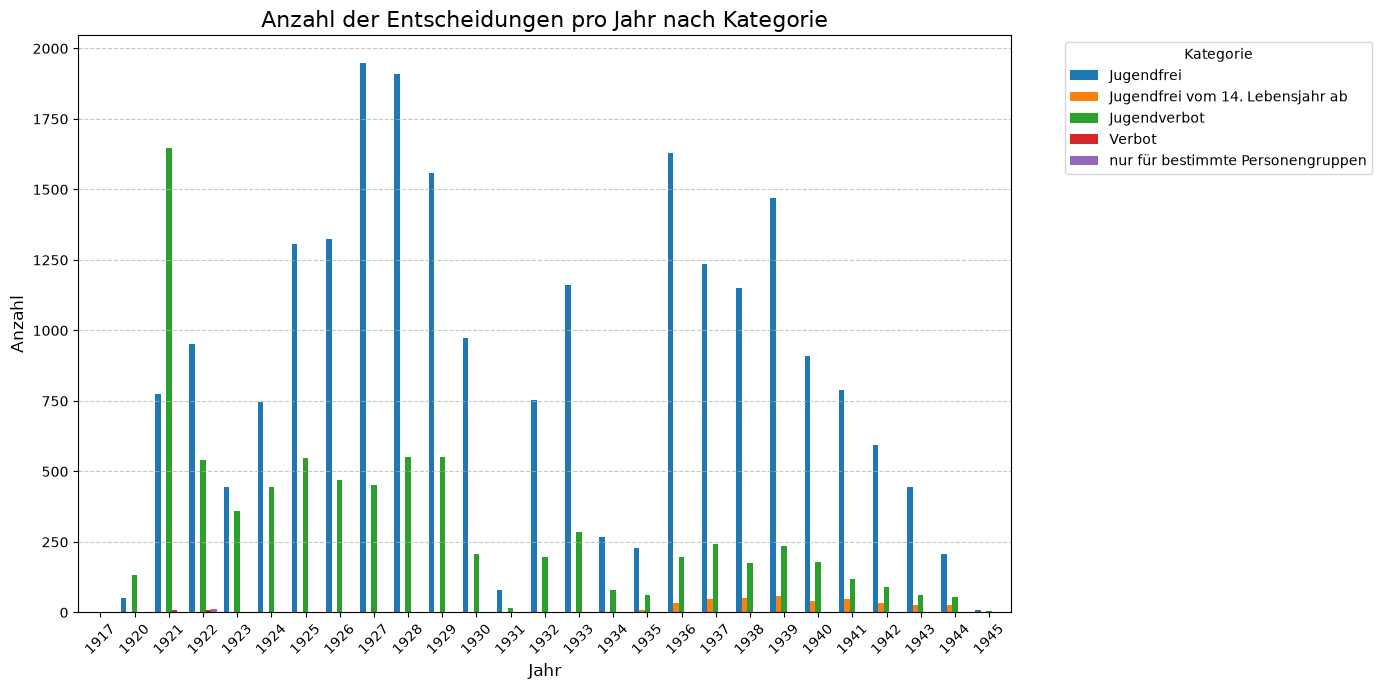

In [84]:
df_grouped = df.groupby(['Jahr', 'Entscheidung']).size().unstack(fill_value=0)

ax = df_grouped.plot(kind='bar', figsize=(14, 7), width=0.8)

plt.title('Anzahl der Entscheidungen pro Jahr nach Kategorie', fontsize=16)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Anzahl', fontsize=12)
plt.legend(title='Kategorie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()


## filmtypes

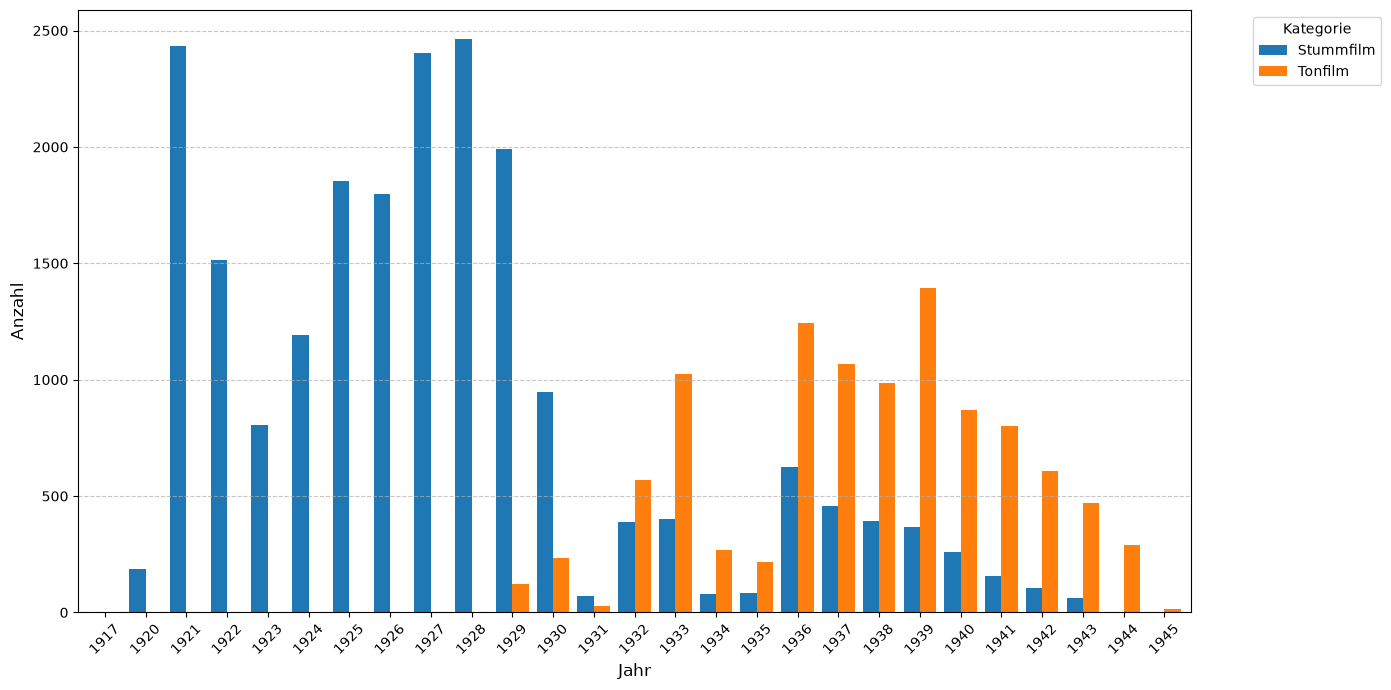

In [85]:
df_grouped = df.groupby(['Jahr', 'Stumm-/Tonfilm']).size().unstack(fill_value=0)

ax = df_grouped.plot(kind='bar', figsize=(14, 7), width=0.8)

#plt.title('Anzahl der Entscheidungen pro Jahr nach Kategorie', fontsize=16)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Anzahl', fontsize=12)
plt.legend(title='Kategorie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()


## Filmtypes

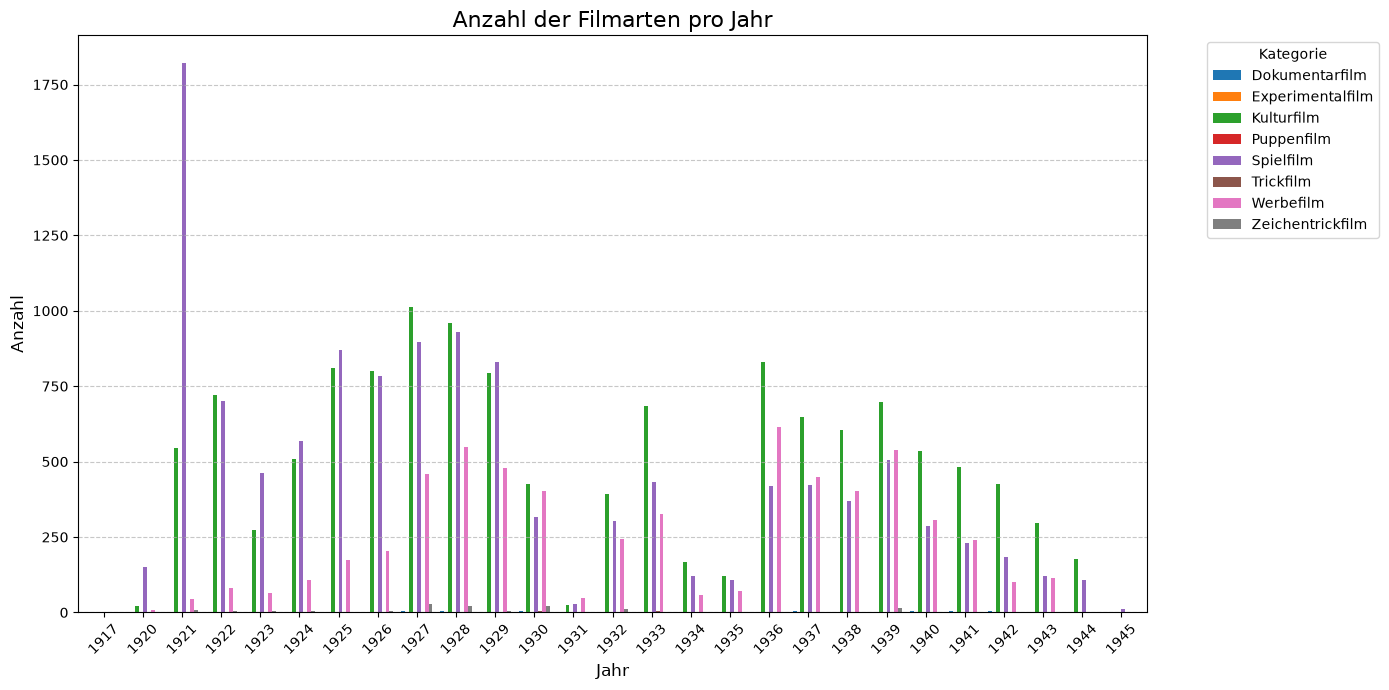

In [86]:
df_grouped = df.groupby(['Jahr', 'Filmart']).size().unstack(fill_value=0)

ax = df_grouped.plot(kind='bar', figsize=(14, 7), width=0.8)

plt.title('Anzahl der Filmarten pro Jahr', fontsize=16)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Anzahl', fontsize=12)
plt.legend(title='Kategorie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()


##

In [87]:
# df_grouped = df.groupby(['Jahr', 'Produktion']).size().unstack(fill_value=0)

# ax = df_grouped.plot(kind='bar', figsize=(14, 7), width=0.8)

# plt.title('Anzahl der Filmarten pro Jahr', fontsize=16)
# plt.xlabel('Jahr', fontsize=12)
# plt.ylabel('Anzahl', fontsize=12)
# plt.legend(title='Kategorie', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.xticks(rotation=45) 
# plt.grid(axis='y', linestyle='--', alpha=0.7) 

# plt.tight_layout()
# plt.show()


In [88]:
# df_grouped = df.groupby(['Jahr', 'Land']).size().unstack(fill_value=0)

# ax = df_grouped.plot(kind='bar', figsize=(14, 7), width=0.8)

# plt.title('Anzahl der Filmarten pro Jahr', fontsize=16)
# plt.xlabel('Jahr', fontsize=12)
# plt.ylabel('Anzahl', fontsize=12)
# plt.legend(title='Kategorie', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.xticks(rotation=45) 
# plt.grid(axis='y', linestyle='--', alpha=0.7) 

# plt.tight_layout()
# plt.show()
